# AF3 modelling of alpha/beta hydrolase (2090) vs a selected set of phopholipids for which experimental assys have been performed.

- PA = phosphatidic acid
- PC = Phosphatidylcholine
- PS = Phosphatidylserine
- PE = Phosphatidylethanolamine
- PI = Phosphatidylinositol


In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem

cwd = os.getcwd()
if cwd.endswith('notebook'):
    os.chdir('..')
    cwd = os.getcwd()

In [3]:
base_folder = Path(os.path.expanduser('~')) / 'Documents' / 'Chahrazad'
assert base_folder.is_dir()

data_folder = base_folder / 'lipids_exp'
assert data_folder.is_dir()

In [5]:
scores_df = pd.read_csv(data_folder / 'modelling' / 'af3' / 'scores.csv')
scores_df = scores_df.sort_values(['posebusters_score', 'confidence', 'aev_plig_pK'], ascending=False).reset_index()
scores_df.head()

,index,protein_name,ligand_name,seed,sample,structure_file,ptm,iptm,confidence,posebusters_score,energy_ratio,posebusters_errors,aev_plig_pK
0,6,ab_hydrolase,PS,664,2,/home/rs1521/Chahrazad/lipids_exp/modelling/af...,0.94,0.85,0.868,20.0,7.6,NaN,NaN
1,7,ab_hydrolase,PS,583,2,/home/rs1521/Chahrazad/lipids_exp/modelling/af...,0.93,0.84,0.858,20.0,7.8,NaN,NaN
2,8,ab_hydrolase,PS,651,1,/home/rs1521/Chahrazad/lipids_exp/modelling/af...,0.93,0.82,0.842,20.0,13.7,NaN,NaN
3,9,ab_hydrolase,PA,830,3,/home/rs1521/Chahrazad/lipids_exp/modelling/af...,0.92,0.80,0.824,20.0,7.1,NaN,NaN
4,10,ab_hydrolase,PA,619,0,/home/rs1521/Chahrazad/lipids_exp/modelling/af...,0.93,0.79,0.818,20.0,4.3,NaN,NaN


In [8]:
best_scores = scores_df[scores_df['posebusters_score'] == 20].copy()
best_scores

,index,protein_name,ligand_name,seed,sample,structure_file,ptm,iptm,confidence,posebusters_score,energy_ratio,posebusters_errors,aev_plig_pK
0,6,ab_hydrolase,PS,664,2,/home/rs1521/Chahrazad/lipids_exp/modelling/af...,0.94,0.85,0.868,20.0,7.6,NaN,NaN
1,7,ab_hydrolase,PS,583,2,/home/rs1521/Chahrazad/lipids_exp/modelling/af...,0.93,0.84,0.858,20.0,7.8,NaN,NaN
2,8,ab_hydrolase,PS,651,1,/home/rs1521/Chahrazad/lipids_exp/modelling/af...,0.93,0.82,0.842,20.0,13.7,NaN,NaN
3,9,ab_hydrolase,PA,830,3,/home/rs1521/Chahrazad/lipids_exp/modelling/af...,0.92,0.80,0.824,20.0,7.1,NaN,NaN
4,10,ab_hydrolase,PA,619,0,/home/rs1521/Chahrazad/lipids_exp/modelling/af...,0.93,0.79,0.818,20.0,4.3,NaN,NaN
5,0,ab_hydrolase,PE,438,0,/home/rs1521/Chahrazad/lipids_exp/modelling/af...,0.92,0.79,0.816,20.0,4.5,NaN,5.72
6,2,ab_hydrolase,PE,438,3,/home/rs1521/Chahrazad/lipids_exp/modelling/af...,0.92,0.79,0.816,20.0,5.4,NaN,5.50
7,11,ab_hydrolase,PA,619,1,/home/rs1521/Chahrazad/lipids_exp/modelling/af...,0.92,0.79,0.816,20.0,4.7,NaN,NaN
8,12,ab_hydrolase,PS,695,2,/home/rs1521/Chahrazad/lipids_exp/modelling/af...,0.92,0.79,0.816,20.0,7.4,NaN,NaN
9,13,ab_hydrolase,PS,651,4,/home/rs1521/Chahrazad/lipids_exp/modelling/af...,0.92,0.79,0.816,20.0,11.3,NaN,NaN


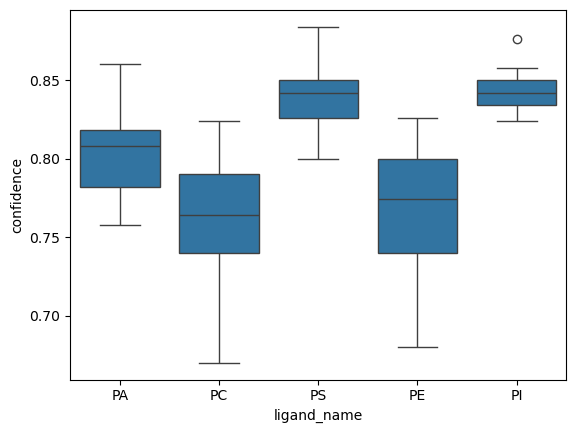

In [13]:
ax = sns.boxplot(scores_df, x='ligand_name', y='confidence', order=['PA', 'PC', 'PS', 'PE', 'PI']);

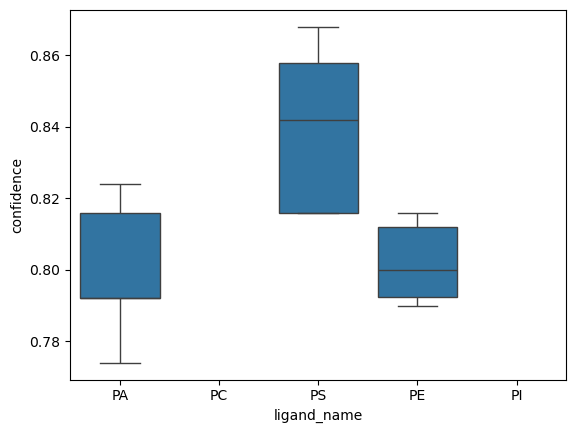

In [14]:
ax = sns.boxplot(best_scores, x='ligand_name', y='confidence', order=['PA', 'PC', 'PS', 'PE', 'PI']);